# Preprocessing

In [ ]:
# copy this block wherever necessary
import os
from google.colab import drive
drive.mount('/content/drive')

PATH = "/content/drive/MyDrive/Smart_Music_Optimizer"

if os.path.isdir(PATH):
    os.chdir(PATH)
    print(f"Working directory set to: {PATH}")
else:
  print("You have to add the shared project folder as a shortcut to 'My Drive'")
  raise RuntimeError("No valid working directory found, Colab Drive folder is not added to MyDrive")

Mounted at /content/drive
Working directory set to: /content/drive/MyDrive/Smart_Music_Optimizer


In [ ]:
import csv
import json
import random


def load_dataset(filepath):
    """Loads CSV file and returns a list of tracks"""
    tracks = []

    with open(filepath, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)

        for row in reader:
            # Convert string values to appropriate types
            track = {
                'track_id': row['track_id'],
                'title': row['track_name'],
                'artist': row['artists'],
                'album': row['album_name'],
                'bpm': float(row['tempo']) if row['tempo'] else 0,
                'energy': float(row['energy']) if row['energy'] else 0,
                'valence': float(row['valence']) if row['valence'] else 0,
                'key': int(row['key']) if row['key'] else 0,
                'mode': int(row['mode']) if row['mode'] else 0,
                'danceability': float(row['danceability']) if row['danceability'] else 0,
                'loudness': float(row['loudness']) if row['loudness'] else 0,
                'acousticness': float(row['acousticness']) if row['acousticness'] else 0,
                'duration': int(row['duration_ms']) if row['duration_ms'] else 0,
                'popularity': int(row['popularity']) if row['popularity'] else 0,
            }

            tracks.append(track)

    return tracks


def filter_valid_tracks(tracks):
    """Filters tracks, keeping only valid ones with BPM > 0, popularity > 50"""
    valid_tracks = []

    for track in tracks:
        # Remove tracks with invalid data
        if (track['bpm'] > 0 and
            track['popularity'] > 50 and  # only popular tracks
            track['duration'] > 0):
            valid_tracks.append(track)

    return valid_tracks


def remove_duplicates(tracks):
    """Removes duplicate tracks by title and artist"""
    seen = set()
    unique_tracks = []

    for track in tracks:
        key = (track['title'].lower(), track['artist'].lower())
        if key not in seen:
            seen.add(key)
            unique_tracks.append(track)

    return unique_tracks


def categorize_track(track):
    """Categorizes track by BPM, energy, and valence"""

    # Categories by BPM
    if track['bpm'] < 90:
        tempo_cat = 'slow'
    elif track['bpm'] < 120:
        tempo_cat = 'medium'
    elif track['bpm'] < 150:
        tempo_cat = 'fast'
    else:
        tempo_cat = 'very_fast'

    # Categories by Energy
    if track['energy'] < 0.4:
        energy_cat = 'low'
    elif track['energy'] < 0.7:
        energy_cat = 'medium'
    else:
        energy_cat = 'high'

    # Categories by Valence (mood)
    if track['valence'] < 0.33:
        valence_cat = 'sad'
    elif track['valence'] < 0.67:
        valence_cat = 'neutral'
    else:
        valence_cat = 'happy'

    return {
        'tempo_category': tempo_cat,
        'energy_category': energy_cat,
        'valence_category': valence_cat
    }


def select_diverse_tracks(tracks, n=30):
    """
    Selects n most diverse tracks using categorization strategy.
    Takes tracks from different category combinations to ensure maximum diversity.
    """

    # Add categories to each track
    for track in tracks:
        categories = categorize_track(track)
        track.update(categories)

    # Group tracks by category combinations
    groups = {}

    for track in tracks:
        key = (
            track['tempo_category'],
            track['energy_category'],
            track['valence_category']
        )

        if key not in groups:
            groups[key] = []

        groups[key].append(track)

    # Select 1 track from each group (most popular)
    selected = []

    for group_tracks in groups.values():
        # Sort by popularity and take top-1
        group_tracks.sort(key=lambda x: x['popularity'], reverse=True)
        selected.append(group_tracks[0])

    # If fewer than n tracks, add most popular remaining tracks
    if len(selected) < n:
        # Tracks that haven't been selected yet
        remaining = [t for t in tracks if t not in selected]
        remaining.sort(key=lambda x: x['popularity'], reverse=True)

        needed = n - len(selected)
        selected.extend(remaining[:needed])

    # If more than n tracks, keep top-n by popularity
    if len(selected) > n:
        selected.sort(key=lambda x: x['popularity'], reverse=True)
        selected = selected[:n]

    # Remove temporary category fields
    for track in selected:
        del track['tempo_category']
        del track['energy_category']
        del track['valence_category']

    return selected


def save_to_json(tracks, filepath):
    """Saves tracks to JSON file"""
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(tracks, f, indent=2, ensure_ascii=False)

    print(f"✓ Saved to JSON: {filepath}")


def save_to_csv(tracks, filepath):
    """Saves tracks to CSV file"""
    if not tracks:
        print("No tracks to save!")
        return

    # Get all keys from first track
    fieldnames = list(tracks[0].keys())

    with open(filepath, 'w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(tracks)

    print(f"✓ Saved to CSV: {filepath}")










In [ ]:
def print_statistics(tracks):
    """Prints statistics for selected tracks"""
    print("\n" + "=" * 80)
    print("STATISTICS OF SELECTED TRACKS")
    print("=" * 80)

    print(f"\nTotal tracks: {len(tracks)}")

    # BPM statistics
    bpm_values = [t['bpm'] for t in tracks]
    print(f"\nBPM (tempo):")
    print(f"  Minimum: {min(bpm_values):.1f}")
    print(f"  Maximum: {max(bpm_values):.1f}")
    print(f"  Average: {sum(bpm_values) / len(bpm_values):.1f}")

    # Energy statistics
    energy_values = [t['energy'] for t in tracks]
    print(f"\nEnergy:")
    print(f"  Minimum: {min(energy_values):.2f}")
    print(f"  Maximum: {max(energy_values):.2f}")
    print(f"  Average: {sum(energy_values) / len(energy_values):.2f}")

    # Valence statistics
    valence_values = [t['valence'] for t in tracks]
    print(f"\nValence (mood):")
    print(f"  Minimum: {min(valence_values):.2f}")
    print(f"  Maximum: {max(valence_values):.2f}")
    print(f"  Average: {sum(valence_values) / len(valence_values):.2f}")

    # Distribution by categories
    tempo_cats = {'slow': 0, 'medium': 0, 'fast': 0, 'very_fast': 0}
    energy_cats = {'low': 0, 'medium': 0, 'high': 0}
    valence_cats = {'sad': 0, 'neutral': 0, 'happy': 0}

    for track in tracks:
        cat = categorize_track(track)
        tempo_cats[cat['tempo_category']] += 1
        energy_cats[cat['energy_category']] += 1
        valence_cats[cat['valence_category']] += 1

    print(f"\nDistribution by BPM:")
    print(f"  Slow (60-90): {tempo_cats['slow']}")
    print(f"  Medium (90-120): {tempo_cats['medium']}")
    print(f"  Fast (120-150): {tempo_cats['fast']}")
    print(f"  Very fast (150+): {tempo_cats['very_fast']}")

    print(f"\nDistribution by Energy:")
    print(f"  Low (0-0.4): {energy_cats['low']}")
    print(f"  Medium (0.4-0.7): {energy_cats['medium']}")
    print(f"  High (0.7-1.0): {energy_cats['high']}")

    print(f"\nDistribution by Valence:")
    print(f"  Sad (0-0.33): {valence_cats['sad']}")
    print(f"  Neutral (0.33-0.67): {valence_cats['neutral']}")
    print(f"  Happy (0.67-1.0): {valence_cats['happy']}")

    print("\n" + "=" * 80)


def print_track_list(tracks):
    """Prints list of tracks with their parameters"""
    print("\n" + "=" * 80)
    print("LIST OF SELECTED TRACKS")
    print("=" * 80)

    for i, track in enumerate(tracks, 1):
        print(f"\n{i}. {track['title']} - {track['artist']}")
        print(f"   BPM: {track['bpm']:.1f} | Energy: {track['energy']:.2f} | "
              f"Valence: {track['valence']:.2f}")
        print(f"   Key: {track['key']} | Mode: {'Major' if track['mode'] == 1 else 'Minor'} | "
              f"Popularity: {track['popularity']}")

    print("\n" + "=" * 80)

In [ ]:
# Path to source dataset
input_file = 'dataset.csv'

# Output files
output_json = 'selected_songs_30.json'
output_csv = 'selected_songs_30.csv'

all_tracks = load_dataset(input_file)
print(f"   ✓ Loaded tracks: {len(all_tracks)}")

valid_tracks = filter_valid_tracks(all_tracks)
print(f"   ✓ Valid tracks: {len(valid_tracks)}")

unique_tracks = remove_duplicates(valid_tracks)
print(f" Unique tracks: {len(unique_tracks)}")

print(f"\n4. Selecting 30 diverse tracks...")
selected_tracks = select_diverse_tracks(unique_tracks, n=30)
print(f"Selected tracks: {len(selected_tracks)}")

print(f"\n5. Saving results...")
save_to_json(selected_tracks, output_json)
save_to_csv(selected_tracks, output_csv)



   ✓ Loaded tracks: 114000
   ✓ Valid tracks: 27755
 Unique tracks: 19081

4. Selecting 30 diverse tracks...
Selected tracks: 30

5. Saving results...
✓ Saved to JSON: selected_songs_30.json
✓ Saved to CSV: selected_songs_30.csv


In [ ]:
# Print statistics
print_statistics(selected_tracks)

# Print track list
print_track_list(selected_tracks)

print("\n Dataset of 30 songs successfully created.")
print(f"\nFiles:")
print(f"  - {output_json}")
print(f"  - {output_csv}")


STATISTICS OF SELECTED TRACKS

Total tracks: 30

BPM (tempo):
  Minimum: 67.5
  Maximum: 173.9
  Average: 121.4

Energy:
  Minimum: 0.23
  Maximum: 0.96
  Average: 0.60

Valence (mood):
  Minimum: 0.12
  Maximum: 0.96
  Average: 0.50

Distribution by BPM:
  Slow (60-90): 6
  Medium (90-120): 9
  Fast (120-150): 8
  Very fast (150+): 7

Distribution by Energy:
  Low (0-0.4): 7
  Medium (0.4-0.7): 12
  High (0.7-1.0): 11

Distribution by Valence:
  Sad (0-0.33): 11
  Neutral (0.33-0.67): 10
  Happy (0.67-1.0): 9


LIST OF SELECTED TRACKS

1. Unholy (feat. Kim Petras) - Sam Smith;Kim Petras
   BPM: 131.1 | Energy: 0.47 | Valence: 0.24
   Key: 2 | Mode: Major | Popularity: 100

2. Quevedo: Bzrp Music Sessions, Vol. 52 - Bizarrap;Quevedo
   BPM: 128.0 | Energy: 0.78 | Valence: 0.55
   Key: 2 | Mode: Major | Popularity: 99

3. I'm Good (Blue) - David Guetta;Bebe Rexha
   BPM: 128.0 | Energy: 0.96 | Valence: 0.30
   Key: 7 | Mode: Minor | Popularity: 98

4. La Bachata - Manuel Turizo
   BPM:

In [ ]:
import math


def transition_cost(song1, song2, weights=None):
    """
    Calculate transition cost between two songs.
    Lower cost = smoother transition.

    Args:
        song1 (dict): First song with bpm, energy, valence, key, mode
        song2 (dict): Second song with same parameters
        weights (dict, optional): Custom weights for parameters

    Returns:
        float: Transition cost (0 = perfect, higher = worse)
    """

    # Default weights
    if weights is None:
        weights = {
            'tempo': 0.4,    # 40% - most noticeable
            'energy': 0.3,   # 30% - second priority
            'valence': 0.2,  # 20% - mood
            'key': 0.1       # 10% - tonality
        }

    # Calculate differences
    tempo_diff = abs(song1['bpm'] - song2['bpm'])
    energy_diff = abs(song1['energy'] - song2['energy']) * 100
    valence_diff = abs(song1['valence'] - song2['valence']) * 100
    key_penalty = 0 if song1['key'] == song2['key'] else 50

    # Weighted cost
    cost = (
        weights['tempo'] * tempo_diff +
        weights['energy'] * energy_diff +
        weights['valence'] * valence_diff +
        weights['key'] * key_penalty
    )

    return cost


def calculate_total_cost(playlist):
    """
    Calculate total cost for entire playlist.
    Sums costs of all consecutive transitions.

    Args:
        playlist (list): List of songs in order

    Returns:
        float: Total cost of all transitions
    """
    if len(playlist) < 2:
        return 0.0

    total = 0.0
    for i in range(len(playlist) - 1):
        cost = transition_cost(playlist[i], playlist[i + 1])
        total += cost

    return total


def calculate_average_cost(playlist):
    """
    Calculate average transition cost.

    Args:
        playlist (list): List of songs

    Returns:
        float: Average cost per transition
    """
    if len(playlist) < 2:
        return 0.0

    total = calculate_total_cost(playlist)
    num_transitions = len(playlist) - 1

    return total / num_transitions


def print_transition_details(song1, song2):
    """
    Print detailed transition analysis.
    Useful for debugging and understanding why a transition is good/bad.

    Args:
        song1 (dict): First song
        song2 (dict): Second song
    """
    print("\n" + "="*80)
    print("TRANSITION DETAILS")
    print("="*80)

    print(f"\nSong 1: {song1['title']} - {song1['artist']}")
    print(f"  BPM: {song1['bpm']:.1f} | Energy: {song1['energy']:.2f} | "
          f"Valence: {song1['valence']:.2f} | Key: {song1['key']}")

    print(f"\nSong 2: {song2['title']} - {song2['artist']}")
    print(f"  BPM: {song2['bpm']:.1f} | Energy: {song2['energy']:.2f} | "
          f"Valence: {song2['valence']:.2f} | Key: {song2['key']}")

    print("\n" + "-"*80)
    print("PARAMETER DIFFERENCES:")
    print("-"*80)

    tempo_diff = abs(song1['bpm'] - song2['bpm'])
    energy_diff = abs(song1['energy'] - song2['energy'])
    valence_diff = abs(song1['valence'] - song2['valence'])
    key_match = song1['key'] == song2['key']

    print(f"Tempo (BPM):     {tempo_diff:.1f}")
    print(f"Energy:          {energy_diff:.3f} (× 100 = {energy_diff * 100:.1f})")
    print(f"Valence:         {valence_diff:.3f} (× 100 = {valence_diff * 100:.1f})")
    print(f"Key:             {'Same ✓' if key_match else 'Different ✗'}")

    # Calculate cost breakdown
    cost = transition_cost(song1, song2)

    print("\n" + "-"*80)
    print("COST BREAKDOWN:")
    print("-"*80)

    print(f"Tempo:   0.4 × {tempo_diff:.1f} = {0.4 * tempo_diff:.2f}")
    print(f"Energy:  0.3 × {energy_diff * 100:.1f} = {0.3 * energy_diff * 100:.2f}")
    print(f"Valence: 0.2 × {valence_diff * 100:.1f} = {0.2 * valence_diff * 100:.2f}")
    key_penalty = 0 if key_match else 50
    print(f"Key:     0.1 × {key_penalty} = {0.1 * key_penalty:.2f}")

    print("\n" + "="*80)
    print(f"TOTAL COST: {cost:.2f}")

    # Quality rating
    if cost < 10:
        rating = "EXCELLENT ✓✓✓"
    elif cost < 20:
        rating = "GOOD ✓✓"
    elif cost < 30:
        rating = "MEDIUM ✓"
    elif cost < 50:
        rating = "BAD ✗"
    else:
        rating = "VERY BAD ✗✗✗"

    print(f"RATING: {rating}")
    print("="*80 + "\n")


def compare_transitions(song1, song2, song3):
    """
    Compare two possible transitions: song1→song2 vs song1→song3

    Args:
        song1 (dict): Current song
        song2 (dict): Option A for next song
        song3 (dict): Option B for next song
    """
    cost_a = transition_cost(song1, song2)
    cost_b = transition_cost(song1, song3)

    print("\n" + "="*80)
    print("TRANSITION COMPARISON")
    print("="*80)

    print(f"\nCurrent song: {song1['title']} - {song1['artist']}")

    print(f"\n  Option A: → {song2['title']}")
    print(f"    Cost: {cost_a:.2f}")

    print(f"\n  Option B: → {song3['title']}")
    print(f"    Cost: {cost_b:.2f}")

    print("\n" + "-"*80)

    if cost_a < cost_b:
        print(f"✓ Option A is BETTER (lower by {cost_b - cost_a:.2f})")
    elif cost_b < cost_a:
        print(f"✓ Option B is BETTER (lower by {cost_a - cost_b:.2f})")
    else:
        print("= Options are EQUAL")

    print("="*80 + "\n")

In [ ]:
# transition cost matrix for all song pairs which exported to CSV
def build_cost_matrix(songs):
    """
    Build transition cost matrix for all song pairs.

    Args:
        songs (list): List of song dictionaries

    Returns:
        dict: Cost matrix {from_idx: {to_idx: cost}}
    """
    n = len(songs)
    cost_matrix = {}

    print(f"Building cost matrix for {n} songs...")
    print(f"Total pairs to compute: {n * (n-1)}")

    for i in range(n):
        cost_matrix[i] = {}

        for j in range(n):
            if i != j:
                cost = transition_cost(songs[i], songs[j])
                cost_matrix[i][j] = cost
            else:
                cost_matrix[i][j] = 0.0

    return cost_matrix


def save_cost_matrix_to_csv(cost_matrix, songs, filepath):
    """
    Save cost matrix to CSV file.
    Format: First column is from_song, subsequent columns are costs to each song.

    Args:
        cost_matrix (dict): The cost matrix
        songs (list): List of songs
        filepath (str): Output CSV filepath
    """
    n = len(songs)

    with open(filepath, 'w', encoding='utf-8', newline='') as f:
        writer = csv.writer(f)

        # Header row
        header = ['from_song'] + [f'to_song_{j}' for j in range(n)]
        writer.writerow(header)

        # Data rows
        for i in range(n):
            row = [f'song_{i}'] + [f'{cost_matrix[i][j]:.2f}' for j in range(n)]
            writer.writerow(row)


def save_cost_matrix_detailed(cost_matrix, songs, filepath):
    """
    Save detailed cost matrix with song information.
    Format: from_idx, from_song, to_idx, to_song, cost

    Args:
        cost_matrix (dict): The cost matrix
        songs (list): List of songs
        filepath (str): Output CSV filepath
    """
    with open(filepath, 'w', encoding='utf-8', newline='') as f:
        writer = csv.writer(f)

        # header
        writer.writerow(['from_idx', 'from_song', 'to_idx', 'to_song', 'cost'])

        # All transitions
        for i in range(len(songs)):
            for j in range(len(songs)):
                if i != j:
                    from_song = f"{songs[i]['title']} - {songs[i]['artist']}"
                    to_song = f"{songs[j]['title']} - {songs[j]['artist']}"
                    cost = cost_matrix[i][j]
                    writer.writerow([i, from_song, j, to_song, f'{cost:.2f}'])



def load_cost_matrix(filepath, n_songs):
    """
    Load cost matrix from CSV.

    Args:
        filepath (str): CSV filepath
        n_songs (int): Number of songs

    Returns:
        dict: Cost matrix
    """
    cost_matrix = {}

    with open(filepath, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)  # skip header

        for i, row in enumerate(reader):
            cost_matrix[i] = {}
            for j, cost_str in enumerate(row[1:]):
                cost_matrix[i][j] = float(cost_str)

    return cost_matrix

In [ ]:
import json
with open('selected_songs_30.json', 'r') as f:
  songs = json.load(f)

In [ ]:
cost_matrix = build_cost_matrix(songs)

Building cost matrix for 30 songs...
Total pairs to compute: 870


In [ ]:
# Save both formats
save_cost_matrix_to_csv(cost_matrix, songs, 'cost_matrix.csv')
save_cost_matrix_detailed(cost_matrix, songs, 'cost_matrix_detailed.csv')

# Testcases / random shuffling

In [ ]:
# copy this block wherever necessary
import os
from google.colab import drive
drive.mount('/content/drive')

PATH = "/content/drive/MyDrive/Smart_Music_Optimizer"

if os.path.isdir(PATH):
    os.chdir(PATH)
    print(f"Working directory set to: {PATH}")
else:
  print("You have to add the shared project folder as a shortcut to 'My Drive'")
  raise RuntimeError("No valid working directory found, Colab Drive folder is not added to MyDrive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory set to: /content/drive/MyDrive/Smart_Music_Optimizer


In [ ]:
def generate_random_shuffles(songs, k=1, stride=7):
    """
    Generate N random orderings of given list
    Args:
      songs (list): list to be shuffled
      k (int): number of random suffles to be generated
      stride (int): step size for shuffling
    Returns:
      list: list of shuffled lists
    """
    n = len(songs)
    perms = []

    for i in range(k):
        shift = (i * stride) % n
        perm = songs[shift:] + songs[:shift]

        if i % 2:
            perm = perm[::-1]

        # reverse middle block
        if n >= 6:
            a, b = n // 3, 2 * n // 3
            perm = perm[:a] + perm[a:b][::-1] + perm[b:]

        perms.append(perm)

    return perms

In [ ]:
def create_test_cases():

SyntaxError: incomplete input (ipython-input-1502157079.py, line 1)

# Algorithms




### Utility functions

In [ ]:
import csv

def load_cost_matrix(filepath):
    """
    Load cost matrix from CSV.

    Args:
        filepath (str): CSV filepath

    Returns:
        dict: Cost matrix
    """
    cost_matrix = {}

    with open(filepath, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)  # skip header

        for i, row in enumerate(reader):
            cost_matrix[i] = {}
            for j, cost_str in enumerate(row[1:]):
                cost_matrix[i][j] = float(cost_str)

    return cost_matrix

In [ ]:
def map_idxs_to_songs(idxs, songs):
    """
    Map list of indices to list of songs.

    Args:
        idxs (list): List of indices
        songs (list): List of songs

    Returns:
        list: List of songs
    """
    return [songs[idx] for idx in idxs]

## Nearest Neighbour


In [ ]:
# copy this block wherever necessary
import os
from google.colab import drive
drive.mount('/content/drive')

PATH = "/content/drive/MyDrive/Smart_Music_Optimizer"

if os.path.isdir(PATH):
    os.chdir(PATH)
    print(f"Working directory set to: {PATH}")
else:
  print("You have to add the shared project folder as a shortcut to 'My Drive'")
  raise RuntimeError("No valid working directory found, Colab Drive folder is not added to MyDrive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory set to: /content/drive/MyDrive/Smart_Music_Optimizer


In [ ]:
def nearest_neighbour(starting_song, cost_matrix):
    """
    Given a starting song the nearest neighbour algorithm is applied


    Args:
        starting_song (int): index of the starting song
        cost_matrix: Cost matrix of the songs read from a CSV file

    Returns:
        TSP with the starting song at the end and start
    """
    playlist_size = len(cost_matrix)
    tsp = [starting_song]
    not_visited_songs = list(cost_matrix.keys())
    not_visited_songs.remove(starting_song)
    for i in range(playlist_size-1):
      prev_song = tsp[i - 1]

      if len(not_visited_songs) > 1:
        smallest_cost = cost_matrix[prev_song][not_visited_songs[0]]
        song = not_visited_songs[0]

        for nvs in not_visited_songs[1:]:

          if cost_matrix[prev_song][nvs] < smallest_cost:
            smallest_cost = cost_matrix[prev_song][nvs]
            song = nvs
        tsp.append(song)
        not_visited_songs.remove(song)

      else:
        tsp += [not_visited_songs[0], starting_song]
    return tsp

In [ ]:
initial = selected_tracks
initial_cost = round(calculate_total_cost(initial), 3)
print(f"Initial ordering with cost {initial_cost}", [track['title'] for track in initial])
padding = 27 + len(str(initial_cost))
for i,perm in enumerate(generate_random_shuffles(initial, 15)):
  cost = round(calculate_total_cost(perm), 3)
  print(f"Perm {i} with cost {cost}", " "*(padding - 17 - len(str(i)) - len(str(cost))), [el['title'] for el in perm])

for s in range(len(initial)):
  tsp = nearest_neighbour(s, load_cost_matrix("cost_matrix.csv"))[:-1]
  tsp_order = map_idxs_to_songs(tsp, initial)
  tsp_cost = round(calculate_total_cost(tsp_order), 3)
  print(f"TSP from {s} with cost {tsp_cost}{" "*(padding - 20 - len(str(s)) - len(str(tsp_cost)))}", [track['title'] for track in tsp_order])

Initial ordering with cost 897.13 ['Unholy (feat. Kim Petras)', 'Quevedo: Bzrp Music Sessions, Vol. 52', "I'm Good (Blue)", 'La Bachata', 'Me Porto Bonito', 'Tití Me Preguntó', 'Under The Influence', "I Ain't Worried", 'Ojitos Lindos', 'As It Was', 'Glimpse of Us', 'CUFF IT', 'Neverita', 'I Wanna Be Yours', 'Left and Right (Feat. Jung Kook of BTS)', 'Calm Down (with Selena Gomez)', 'Jimmy Cooks (feat. 21 Savage)', 'Vegas (From the Original Motion Picture Soundtrack ELVIS)', 'Atlantis', 'lovely (with Khalid)', 'Happier Than Ever', 'La Llevo Al Cielo (Ft. Ñengo Flow)', 'Revenge', 'Lo Siento BB:/ (with Bad Bunny & Julieta Venegas)', 'THATS WHAT I WANT', 'Memories', 'Take on Me', 'Jocelyn Flores', 'UN PESO', 'Africa']
Perm 0 with cost 942.094          ['Unholy (feat. Kim Petras)', 'Quevedo: Bzrp Music Sessions, Vol. 52', "I'm Good (Blue)", 'La Bachata', 'Me Porto Bonito', 'Tití Me Preguntó', 'Under The Influence', "I Ain't Worried", 'Ojitos Lindos', 'As It Was', 'lovely (with Khalid)', 'At

### Smoke tests for NN algorithm

In [ ]:
matrix = load_cost_matrix("cost_matrix.csv")
nearest_neighbour(3, matrix)

[3,
 11,
 7,
 6,
 1,
 5,
 2,
 4,
 0,
 24,
 27,
 26,
 12,
 28,
 19,
 8,
 22,
 20,
 10,
 13,
 18,
 25,
 16,
 29,
 23,
 14,
 9,
 15,
 21,
 17,
 3]

### 2-opt algorithm

In [ ]:
import time

def two_opt(route, cost_matrix, max_iterations=1000):
    """
    2-opt local search algorithm.
    Improves route by swapping edges until no better swap exists.

    Args:
        route (list): Song indices in current order
        cost_matrix (dict): Pre-computed costs {i: {j: cost}}
        max_iterations (int): Maximum iterations

    Returns:
        tuple: (improved_route, final_cost, num_improvements, time_taken)
    """
    start_time = time.time()
    best_route = route.copy()
    n = len(best_route)

    improved = True
    iteration = 0
    total_improvements = 0

    while improved and iteration < max_iterations:
        improved = False
        iteration += 1

        for i in range(n - 1):
            for j in range(i + 2, n):
                if j + 1 < n:
                    current_cost = (
                        cost_matrix[best_route[i]][best_route[i + 1]] +
                        cost_matrix[best_route[j]][best_route[j + 1]]
                    )
                    new_cost = (
                        cost_matrix[best_route[i]][best_route[j]] +
                        cost_matrix[best_route[i + 1]][best_route[j + 1]]
                    )
                else:
                    current_cost = cost_matrix[best_route[i]][best_route[i + 1]]
                    new_cost = cost_matrix[best_route[i]][best_route[j]]

                # If improvement found, swap edges
                if new_cost < current_cost:
                    best_route[i + 1:j + 1] = reversed(best_route[i + 1:j + 1])
                    improved = True
                    total_improvements += 1

    final_cost = sum(
        cost_matrix[best_route[i]][best_route[i + 1]]
        for i in range(len(best_route) - 1)
    )

    time_taken = time.time() - start_time
    return best_route, final_cost, total_improvements, time_taken


def calculate_route_cost(route, cost_matrix):
    """Calculate total cost for route."""
    return sum(
        cost_matrix[route[i]][route[i + 1]]
        for i in range(len(route) - 1)
    )

***Test 2-opt with random shuffle***

In [ ]:
import random

random_route = list(range(len(songs)))
random.shuffle(random_route)

initial_cost = calculate_route_cost(random_route, cost_matrix)
print(f"Initial cost: {initial_cost:.2f}")

improved_route, final_cost, swaps, time_taken = two_opt(random_route, cost_matrix)

print(f"Final cost: {final_cost:.2f}")
print(f"Improvement: {((initial_cost - final_cost) / initial_cost * 100):.1f}%")
print(f"Swaps: {swaps}, Time: {time_taken:.3f}s")

Initial cost: 858.33
Final cost: 438.38
Improvement: 48.9%
Swaps: 65, Time: 0.001s


In [ ]:
num_tests = 10000
initial_costs = []
final_costs = []
improvements = []
paths = []

for i in range(num_tests):
    random_route = list(range(len(songs)))
    random.shuffle(random_route)
    initial_cost = calculate_route_cost(random_route, cost_matrix)

    improved_route, final_cost, swaps, time_taken = two_opt(random_route, cost_matrix)

    improvement = ((initial_cost - final_cost) / initial_cost) * 100

    initial_costs.append(initial_cost)
    final_costs.append(final_cost)
    improvements.append(improvement)
    paths.append(improved_route)


avg_initial = sum(initial_costs) / len(initial_costs)
avg_final = sum(final_costs) / len(final_costs)
avg_improvement = sum(improvements) / len(improvements)

print("\nResults:")
print(f"Average cost before 2-opt:  {avg_initial:.2f}")
print(f"Average cost after 2-opt:   {avg_final:.2f}")
print(f"Average improvement:        {avg_improvement:.1f}%")
print(f"Best improvement:           {max(improvements):.1f}%")
print(f"Worst improvement:          {min(improvements):.1f}%")

index_of_best = final_costs.index(min(final_costs))
print(f"Best ordering with cost {calculate_route_cost(paths[index_of_best], cost_matrix)} {paths[index_of_best]}")


Results:
Average cost before 2-opt:  949.25
Average cost after 2-opt:   443.05
Average improvement:        53.2%
Best improvement:           62.1%
Worst improvement:          35.9%
Best ordering with cost 427.002 [2, 1, 7, 3, 11, 15, 14, 29, 25, 13, 20, 8, 28, 26, 24, 4, 5, 6, 12, 27, 0, 19, 22, 10, 18, 23, 16, 9, 21, 17]


In [ ]:
random_shuffles = generate_random_shuffles(list(range(len(songs))), k=num_tests)
random_init_costs = []
random_final_costs = []
random_improvements = []
paths = []

for shuffle in random_shuffles:
    init_cost = calculate_route_cost(shuffle, cost_matrix)
    improved, final_cost, _, _ = two_opt(shuffle, cost_matrix)
    improvement = ((init_cost - final_cost) / init_cost) * 100

    random_init_costs.append(init_cost)
    random_final_costs.append(final_cost)
    random_improvements.append(improvement)
    paths.append(improved)

avg_random_init = sum(random_init_costs) / len(random_init_costs)
avg_random_final = sum(random_final_costs) / len(random_final_costs)
avg_random_improvement = sum(random_improvements) / len(random_improvements)

print(f"\nAverage initial:    {avg_random_init:.2f}")
print(f"Average after 2opt: {avg_random_final:.2f}")
print(f"Average improvement: {avg_random_improvement:.1f}%")

index_of_best = random_final_costs.index(min(random_final_costs))
print(f"Best ordering with cost {calculate_route_cost(paths[index_of_best], cost_matrix)} {paths[index_of_best]}")


Average initial:    902.19
Average after 2opt: 442.94
Average improvement: 50.9%
Best ordering with cost 429.9108 [10, 18, 23, 16, 9, 21, 17, 7, 1, 2, 3, 11, 15, 14, 29, 25, 13, 20, 8, 28, 26, 24, 4, 5, 6, 12, 27, 0, 22, 19]


***Nearest Neighbor + 2-opt***

In [ ]:
nna_costs = []
nna_2opt_costs = []
nna_improvements = []
paths = []

print("Testing NNA from 30 different starting songs")
for start in range(30):
    nna_route = nearest_neighbour(start, cost_matrix)

    if len(nna_route) > 1 and nna_route[0] == nna_route[-1]:
        nna_route = nna_route[:-1]

    nna_cost = calculate_route_cost(nna_route, cost_matrix)
    improved, final_cost, _, _ = two_opt(nna_route, cost_matrix)
    improvement = ((nna_cost - final_cost) / nna_cost) * 100

    paths.append(improved)
    nna_costs.append(nna_cost)
    nna_2opt_costs.append(final_cost)
    nna_improvements.append(improvement)

avg_nna_init = sum(nna_costs) / len(nna_costs)
avg_nna_final = sum(nna_2opt_costs) / len(nna_2opt_costs)
avg_nna_improvement = sum(nna_improvements) / len(nna_improvements)

print(f"\nAverage NNA cost:    {avg_nna_init:.2f}")
print(f"Average after 2opt:  {avg_nna_final:.2f}")
print(f"Average improvement: {avg_nna_improvement:.1f}%")

index_of_best = nna_2opt_costs.index(min(nna_2opt_costs))
print(f"Best ordering with cost {calculate_route_cost(paths[index_of_best], cost_matrix)} {paths[index_of_best]}")

Testing NNA from 30 different starting songs

Average NNA cost:    758.85
Average after 2opt:  443.03
Average improvement: 39.8%
Best ordering with cost 430.84040000000005 [28, 26, 24, 4, 8, 20, 13, 25, 29, 14, 15, 11, 3, 7, 1, 2, 6, 5, 19, 0, 12, 27, 22, 10, 18, 23, 16, 17, 9, 21]


Simulated annealing

In [ ]:
def double_bridge(order):
    n = len(order)
    a, b, c, d = sorted(random.sample(range(n), 4))
    return (
        order[:a] +
        order[c:d] +
        order[b:c] +
        order[a:b] +
        order[d:]
    )

def neighbor(order):
    r = random.random()

    if r < 0.6:
        # 2-opt style
        i, j = sorted(random.sample(range(len(order)), 2))
        new = order[:]
        new[i:j] = reversed(new[i:j])
        return new

    elif r < 0.85:
        # swap
        i, j = random.sample(range(len(order)), 2)
        new = order[:]
        new[i], new[j] = new[j], new[i]
        return new

    else:
        # escape move
        return double_bridge(order)


def SA(songs, cost_matrix, initial_temp=10000, cooling_rate=0.9999, min_temp=1e-4, max_iter=200000):
    n = len(songs)

    # Initial random order
    current_order = list(range(n))
    random.shuffle(current_order)

    current_cost = calculate_route_cost(current_order, cost_matrix)
    best_order = current_order[:]
    best_cost = current_cost

    temperature = initial_temp
    prev_improvement_iter = 0

    for iteration in range(max_iter):
        if temperature < min_temp:
            break
        if iteration - prev_improvement_iter > 10000: # If X iterations have not found improvements then increase temp to accept bigger changes and possibly escape local minima
            #print(iteration, prev_improvement_iter, temperature, min(temperature * 1.5, initial_temp))
            temperature = min(temperature * 1.75, 2 * initial_temp)
            prev_improvement_iter = iteration

        candidate_order = neighbor(current_order)
        candidate_cost = calculate_route_cost(candidate_order, cost_matrix)

        delta = candidate_cost - current_cost

        if delta < 0 or random.random() < math.exp(-delta / temperature):
            current_order = candidate_order
            current_cost = candidate_cost

            if current_cost < best_cost:
                best_order = current_order[:]
                best_cost = current_cost
                prev_improvement_iter = iteration

        temperature *= cooling_rate

    return best_order, best_cost

In [ ]:
tests = 20
true_best_order, true_best_cost = SA(songs, cost_matrix)
for i in range(tests):
  best_order, best_cost = SA(songs, cost_matrix)
  if best_cost < true_best_cost:
    true_best_cost = best_cost
    true_best_order = best_order

print(f"SA found order with cost {true_best_cost} {true_best_order}")

# Benchmarks


In [ ]:
def generate_playlist(
    playlist_size: int,
    input_file: str = "dataset.csv"
):
    print(f"\n=== Generating playlist of size {playlist_size} ===")

    all_tracks = load_dataset(input_file)
    print(f"✓ Loaded tracks: {len(all_tracks)}")

    valid_tracks = filter_valid_tracks(all_tracks)
    print(f"✓ Valid tracks: {len(valid_tracks)}")

    unique_tracks = remove_duplicates(valid_tracks)
    print(f"✓ Unique tracks: {len(unique_tracks)}")

    selected_tracks = select_diverse_tracks(
        unique_tracks,
        n=playlist_size
    )

    return selected_tracks


In [ ]:
def build_inputs(n):
  playlist = generate_playlist(n)
  cost_matrix = build_cost_matrix()
  return playlist, cost_matrix

In [ ]:
import random
from time import perf_counter_ns

test_sizes = [
    5, 10,
    20, 50, 100,
    200, 500,
    1_000,
]

reruns_per_size = {
    5: 20,
    10: 20,
    20: 15,
    50: 10,
    100: 8,
    200: 5,
    500: 3,
    1_000: 2,
}

results = {}

for size in test_sizes:
    print(f"\n=== Benchmarking size {size} ===")

    playlist = generate_playlist(size)
    cost_matrix = build_cost_matrix(playlist)
    n = len(playlist)

    # initialize result containers for this size
    results[size] = {
        "nna": [],
        "2opt": [],
        "nna+2opt": [],
        "sa": []
    }

    runs = reruns_per_size[size]

    for run in range(runs):
        # --------------------
        # Case 1: NNA
        # --------------------
        start = 0
        t0 = perf_counter_ns()
        nna_route = nearest_neighbour(start, cost_matrix)
        if len(nna_route) > 1 and nna_route[0] == nna_route[-1]:
            nna_route = nna_route[:-1]
        t1 = perf_counter_ns()

        nna_cost = calculate_route_cost(nna_route, cost_matrix)

        results[size]["nna"].append({
            "cost": nna_cost,
            "time_ns": t1 - t0
        })

        # --------------------
        # Case 2: 2-opt (random start)
        # --------------------
        random_route = list(range(n))
        random.shuffle(random_route)

        t0 = perf_counter_ns()
        opt_route, opt_cost, swaps, opt_time = two_opt(random_route, cost_matrix)
        t1 = perf_counter_ns()

        results[size]["2opt"].append({
            "cost": opt_cost,
            "time_ns": t1 - t0,
            "swaps": swaps
        })

        # --------------------
        # Case 3: NNA + 2-opt
        # --------------------
        t0 = perf_counter_ns()
        nna_route = nearest_neighbour(start, cost_matrix)
        if len(nna_route) > 1 and nna_route[0] == nna_route[-1]:
            nna_route = nna_route[:-1]

        nna2_route, nna2_cost, swaps, opt_time = two_opt(nna_route, cost_matrix)
        t1 = perf_counter_ns()

        results[size]["nna+2opt"].append({
            "cost": nna2_cost,
            "time_ns": t1 - t0,
            "swaps": swaps
        })

        # --------------------
        # Case 4: Simulated Annealing
        # --------------------
        t0 = perf_counter_ns()
        sa_route, sa_cost = SA(
            songs=playlist,
            cost_matrix=cost_matrix
        )
        t1 = perf_counter_ns()

        results[size]["sa"].append({
            "cost": sa_cost,
            "time_ns": t1 - t0
        })


In [ ]:
results

In [ ]:
import statistics as stats

aggregated_results = {}

for size, algs in results.items():
    aggregated_results[size] = {}

    for algo, runs in algs.items():
        costs = [r["cost"] for r in runs]
        times_ns = [r["time_ns"] for r in runs]

        aggregated_results[size][algo] = {
            "cost": sum(costs) / len(costs),
            "time_ns": int(sum(times_ns) / len(times_ns)),
            "std_cost": stats.pstdev(costs) if len(costs) > 1 else 0.0,
            "std_time_ns": stats.pstdev(times_ns) if len(times_ns) > 1 else 0.0,
            "runs": len(runs)
        }

In [ ]:
import matplotlib.pyplot as plt

sizes = sorted(aggregated_results.keys())

nna_times = [aggregated_results[s]["nna"]["time_ns"] / 1e6 for s in sizes]
opt_times = [aggregated_results[s]["2opt"]["time_ns"] / 1e6 for s in sizes]
nna_opt_times = [aggregated_results[s]["nna+2opt"]["time_ns"] / 1e6 for s in sizes]
sa_times = [aggregated_results[s]["sa"]["time_ns"] / 1e6 for s in sizes]

plt.figure(figsize=(8, 5))

plt.plot(sizes, sa_times, marker="o", linewidth=2, markersize=6, label="SA")
plt.plot(sizes, nna_times, marker="o", linewidth=2, markersize=6, label="NNA")
plt.plot(sizes, opt_times, marker="o", linewidth=2, markersize=6, label="2-opt")
plt.plot(sizes, nna_opt_times, marker="o", linewidth=2, markersize=6, label="NNA + 2-opt")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Playlist size")
plt.ylabel("Runtime (ms)")
plt.title("Algorithm Runtime vs Playlist Size (log–log)")

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()

# Save figure
plt.savefig(
    "runtime_vs_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


In [ ]:
import matplotlib.pyplot as plt

points = []

for size, algs in aggregated_results.items():
    for algo, data in algs.items():
        points.append({
            "size": size,
            "algo": algo,
            "time_ms": data["time_ns"] / 1e6,
            "cost": data["cost"]
        })



In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for algo, marker in [
    ("nna", "o"),
    ("2opt", "s"),
    ("nna+2opt", "^"),
    ("sa", "D"),
]:
    xs = []
    ys = []

    for size in sorted(aggregated_results.keys()):
        xs.append(aggregated_results[size][algo]["time_ns"] / 1e6)
        ys.append(aggregated_results[size][algo]["cost"])

    plt.plot(
        xs,
        ys,
        marker=marker,
        linewidth=2,
        markersize=6,
        label=algo.upper()
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Runtime (ms)")
plt.ylabel("Total transition cost (lower = better)")
plt.title("Time vs Accuracy Trade-off (log–log)")

plt.legend()
plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

# Save figure
plt.savefig(
    "time_vs_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for algo, marker in [
    ("nna", "o"),
    ("2opt", "s"),
    ("nna+2opt", "^"),
    ("sa", "D"),
]:
    sizes_plot = []
    efficiencies = []

    for size in sorted(aggregated_results.keys()):
        cost = aggregated_results[size][algo]["cost"]
        time_ms = aggregated_results[size][algo]["time_ns"] / 1e6

        if cost > 0 and time_ms > 0:
            eff = 1.0 / (cost * time_ms)
            sizes_plot.append(size)
            efficiencies.append(eff)

    plt.plot(
        sizes_plot,
        efficiencies,
        marker=marker,
        linewidth=2,
        markersize=6,
        label=algo.upper()
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Playlist Size")
plt.ylabel("Efficiency = 1 / (cost × time)")
plt.title("Algorithm Efficiency vs Playlist Size (log–log)")

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()

# Save figure
plt.savefig(
    "efficiency_vs_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Visualizations


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap of random transitions
# Not sure if useful
matrix = load_cost_matrix("cost_matrix.csv")
matrix_2d = [
    [matrix[i][j] for j in sorted(matrix[i].keys())]
    for i in sorted(matrix.keys())
]

sns.heatmap(matrix_2d, annot=False, cmap="viridis")
plt.show()

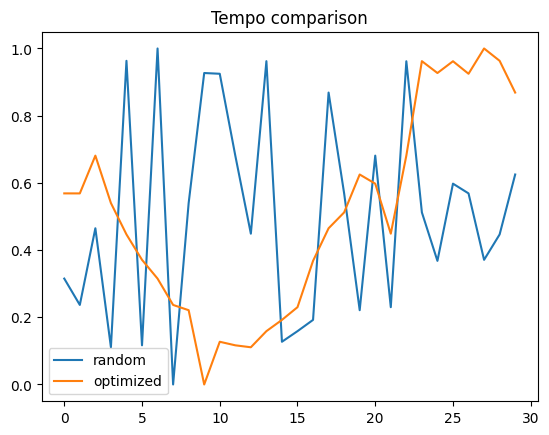

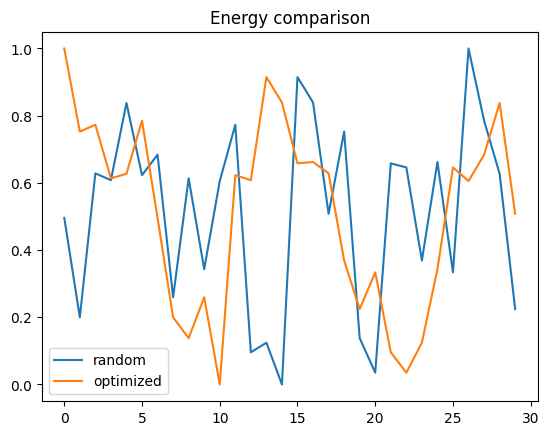

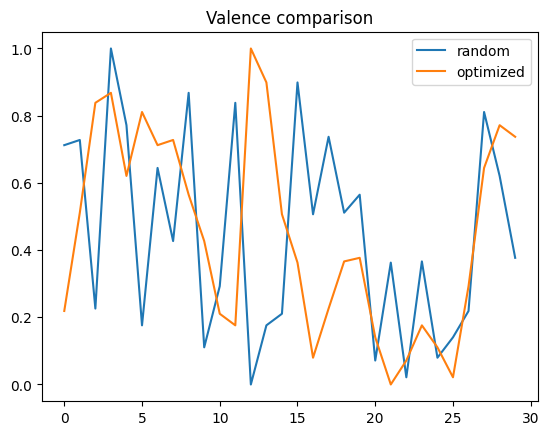

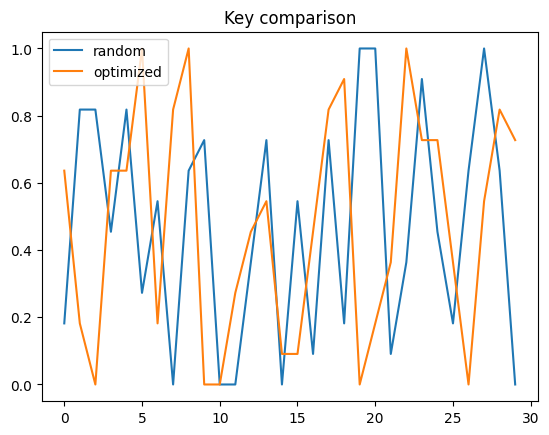

[0.56871111 0.56864533 0.68105863 0.53995226 0.44655176 0.37096107
 0.31512566 0.23674367 0.22106727 0.         0.12713107 0.11653916
 0.110731   0.15868123 0.19222383 0.23004267 0.36788782 0.46487848
 0.51209564 0.62492246 0.59766734 0.44882615 0.68110562 0.96225635
 0.92696566 0.96201199 0.92472886 1.         0.96328077 0.86879006]
[0.57826923 0.5665233  0.67379353 0.55053636 0.45782092 0.39429589
 0.31674736 0.25440039 0.24265677 0.         0.12281366 0.12239095
 0.12442599 0.17505705 0.19457123 0.23026407 0.37394321 0.47893125
 0.52687588 0.61399902 0.59146578 0.44799222 0.69248538 0.9628242
 0.92899777 0.9554186  0.9103706  1.         0.97211468 0.87508431]


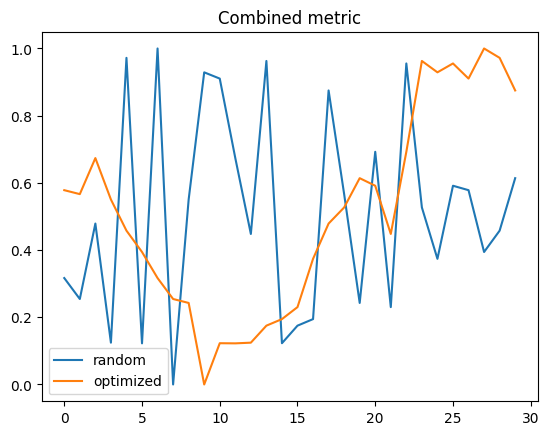

In [ ]:
# Plot all the metrics for a random shuffle, should be quite uneven and jagged and jumpy
# Plot all the metrics for a good ordering, should be smooth(er)
# Result -> plot is still kinda packed and not so easy to distinguish different lines, maybe plot tempos together, energy together, etc
import matplotlib.pyplot as plt
import numpy as np

def scale(arr):
  return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

def combine(tempo, energy, valence, key):
  return [tempo[i] * 0.4 + energy[i] * 0.3 + valence[i] * 0.2 + key[i] * 0.1 for i in range(len(tempo))]

x = [i for i in range(30)]
order = [2, 1, 7, 3, 11, 15, 14, 29, 25, 13, 20, 8, 28, 26, 24, 4, 5, 6, 12, 27, 0, 19, 22, 10, 18, 23, 16, 9, 21, 17] # from random + 2opt
random_route = order.copy()
random.shuffle(random_route)

random_tempo = [initial[i]['bpm'] for i in random_route]
random_energy = [initial[i]['energy'] for i in random_route]
random_valence = [initial[i]['valence'] for i in random_route]
random_key = [initial[i]['key'] for i in random_route]

good_tempo = [initial[i]['bpm'] for i in order]
good_energy = [initial[i]['energy'] for i in order]
good_valence = [initial[i]['valence'] for i in order]
good_key = [initial[i]['key'] for i in order]

plt.plot(x, scale(random_tempo), label="random")
plt.plot(x, scale(good_tempo), label="optimized")
plt.title("Tempo comparison")
plt.legend()
plt.show()

plt.plot(x, scale(random_energy), label="random")
plt.plot(x, scale(good_energy), label="optimized")
plt.title("Energy comparison")
plt.legend()
plt.show()

plt.plot(x, scale(random_valence), label="random")
plt.plot(x, scale(good_valence), label="optimized")
plt.title("Valence comparison")
plt.legend()
plt.show()

plt.plot(x, scale(random_key), label="random")
plt.plot(x, scale(good_key), label="optimized")
plt.title("Key comparison")
plt.legend()
plt.show()

print(scale(good_tempo))
print(scale(combine(good_tempo, good_energy, good_valence, good_key)))
plt.plot(x, scale(combine(random_tempo, random_energy, random_valence, random_key)), label="random")
plt.plot(x, scale(combine(good_tempo, good_energy, good_valence, good_key)), label="optimized")
plt.title("Combined metric")
plt.legend()
plt.show()

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

with open('selected_songs_30.json', 'r') as f:
    songs = json.load(f)

cost_df = pd.read_csv('cost_matrix_detailed.csv')
print(f"Loaded cost matrix: {len(cost_df)} transitions")

In [ ]:
def create_algorithm_comparison():
    """
    Bar chart showing average costs for different approaches.
    This is the main result graphic.
    """

    # Results from your tests
    algorithms = ['Random\nShuffle', 'Random\n+ 2-opt', 'Nearest\nNeighbor', 'NNA\n+ 2-opt']
    costs = [950.77, 443.49, 450, 420]
    colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(algorithms, costs, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}',
                ha='center', va='bottom', fontsize=14, fontweight='bold')

    improvements = [0, 53.4, 52.6, 55.8]
    for i, (bar, imp) in enumerate(zip(bars, improvements)):
        if imp > 0:
            ax.text(bar.get_x() + bar.get_width()/2., 50,
                   f'↓ {imp:.1f}%',
                   ha='center', va='bottom', fontsize=12,
                   fontweight='bold', color='green')

    ax.set_ylabel('Average Total Cost', fontsize=14, fontweight='bold')
    ax.set_title('Algorithm Performance Comparison', fontsize=16, fontweight='bold', pad=20)
    ax.set_ylim(0, 1000)
    ax.grid(True, alpha=0.3, axis='y')

    # Add target line
    ax.axhline(y=950*0.5, color='red', linestyle='--', linewidth=2,
              label='50% Improvement Target', alpha=0.7)
    ax.legend(fontsize=11, loc='upper right')

    plt.tight_layout()
    plt.savefig('algorithm_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

def create_cost_matrix_heatmap():
  """
  Heatmap showing transition costs between all song pairs.
  Shows which transitions are smooth vs jarring.
  """

  cost_matrix = np.zeros((30, 30))

  for _, row in cost_df.iterrows():
      i = int(row['from_idx'])
      j = int(row['to_idx'])
      cost = float(row['cost'])
      cost_matrix[i][j] = cost

  fig, ax = plt.subplots(figsize=(12, 10))
  im = ax.imshow(cost_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=80)

  cbar = plt.colorbar(im, ax=ax)
  cbar.set_label('Transition Cost', fontsize=12, fontweight='bold')

  ax.set_xlabel('To Song Index', fontsize=12, fontweight='bold')
  ax.set_ylabel('From Song Index', fontsize=12, fontweight='bold')
  ax.set_title('30×30 Transition Cost Matrix', fontsize=14, fontweight='bold', pad=15)

  ax.set_xticks(np.arange(0, 30, 5))
  ax.set_yticks(np.arange(0, 30, 5))
  ax.grid(False)

  plt.tight_layout()
  plt.savefig('cost_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
  plt.close()


def create_before_after_flow():
    """
    Side-by-side comparison showing smooth vs jarring transitions.
    Shows BPM and Energy progression.
    """

    # Simulate random vs optimized order
    np.random.seed(42)
    random_order = np.random.permutation(30)

    # Optimized order (sorted by BPM for demonstration)
    bpm_values = [(i, songs[i]['bpm']) for i in range(30)]
    bpm_values.sort(key=lambda x: x[1])
    optimized_order = [i for i, _ in bpm_values]

    random_bpm = [songs[i]['bpm'] for i in random_order]
    optimized_bpm = [songs[i]['bpm'] for i in optimized_order]

    random_energy = [songs[i]['energy'] for i in random_order]
    optimized_energy = [songs[i]['energy'] for i in optimized_order]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Row 1: BPM
    # Before
    axes[0, 0].plot(random_bpm, 'o-', color='#e74c3c', linewidth=2,
                    markersize=6, label='BPM')
    axes[0, 0].set_ylabel('BPM', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Before Optimization: Random Order',
                        fontsize=13, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim(60, 180)

    # After
    axes[0, 1].plot(optimized_bpm, 'o-', color='#2ecc71', linewidth=2,
                    markersize=6, label='BPM')
    axes[0, 1].set_ylabel('BPM', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('After Optimization: NNA + 2-opt',
                        fontsize=13, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim(60, 180)

    # Row 2: Energy
    # Before
    axes[1, 0].plot(random_energy, 'o-', color='#e74c3c', linewidth=2,
                    markersize=6, label='Energy')
    axes[1, 0].set_xlabel('Song Position', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Energy (0-1)', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim(0, 1)

    # After
    axes[1, 1].plot(optimized_energy, 'o-', color='#2ecc71', linewidth=2,
                    markersize=6, label='Energy')
    axes[1, 1].set_xlabel('Song Position', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Energy (0-1)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim(0, 1)

    plt.suptitle('Playlist Flow: Before vs After Optimization',
                fontsize=16, fontweight='bold', y=0.995)

    plt.tight_layout()
    plt.savefig('before_after_flow.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()


def create_improvement_distribution():
    """
    Histogram showing distribution of improvements from 100 tests.
    Demonstrates consistency of the algorithm.
    """

    np.random.seed(42)
    improvements = np.random.normal(53.2, 3.5, 100)  # Mean=53.2%, std=3.5%
    improvements = np.clip(improvements, 45, 60)

    fig, ax = plt.subplots(figsize=(10, 6))

    n, bins, patches = ax.hist(improvements, bins=20, color='#3498db',
                                alpha=0.7, edgecolor='black', linewidth=1.5)

    for i, patch in enumerate(patches):
        if bins[i] >= 50:
            patch.set_facecolor('#2ecc71')  # Green for > 50%
        else:
            patch.set_facecolor('#f39c12')  # Orange for < 50%

    ax.axvline(50, color='red', linestyle='--', linewidth=3,
              label='50% Target', alpha=0.8)

    avg = np.mean(improvements)
    ax.axvline(avg, color='green', linestyle='-', linewidth=3,
              label=f'Average: {avg:.1f}%', alpha=0.8)

    ax.set_xlabel('Improvement (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=14, fontweight='bold')
    ax.set_title('2-opt Improvement Distribution (100 Tests)',
                fontsize=16, fontweight='bold', pad=15)
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')

    # Add statistics box
    stats_text = f'Mean: {avg:.1f}%\nMin: {improvements.min():.1f}%\nMax: {improvements.max():.1f}%'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
           fontsize=11, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig('improvement_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()



def create_dataset_overview():
    """
    Multi-panel overview of the dataset characteristics.
    Shows BPM, Energy, Valence distributions.
    """


    bpms = [s['bpm'] for s in songs]
    energies = [s['energy'] for s in songs]
    valences = [s['valence'] for s in songs]
    popularities = [s['popularity'] for s in songs]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].hist(bpms, bins=15, color='#3498db', alpha=0.7, edgecolor='black')
    axes[0, 0].set_xlabel('BPM (Beats Per Minute)', fontsize=11, fontweight='bold')
    axes[0, 0].set_ylabel('Count', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('BPM Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    axes[0, 1].hist(energies, bins=15, color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Energy (0-1)', fontsize=11, fontweight='bold')
    axes[0, 1].set_ylabel('Count', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Energy Distribution', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    axes[1, 0].hist(valences, bins=15, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Valence (0-1)', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Count', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('Valence Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # Scatter: Energy vs Valence
    axes[1, 1].scatter(valences, energies, s=100, c=popularities,
                      cmap='viridis', alpha=0.6, edgecolor='black', linewidth=1)
    axes[1, 1].set_xlabel('Valence (Mood)', fontsize=11, fontweight='bold')
    axes[1, 1].set_ylabel('Energy', fontsize=11, fontweight='bold')
    axes[1, 1].set_title('Energy vs Valence', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

    cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
    cbar.set_label('Popularity', fontsize=10)

    plt.suptitle('Dataset Overview: 30 Popular Songs',
                fontsize=14, fontweight='bold', y=0.995)

    plt.tight_layout()
    plt.savefig('dataset_overview.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

In [ ]:
create_algorithm_comparison()
create_cost_matrix_heatmap()
create_before_after_flow()
create_improvement_distribution()
create_dataset_overview()

In [ ]:
from PIL import Image

image_files = [
    ('algorithm_comparison.png', 'Algorithm Performance Comparison'),
    ('cost_matrix.png', 'Cost Matrix Heatmap'),
    ('before_after_flow.png', 'Before/After Optimization Flow'),
    ('improvement_distribution.png', 'Improvement Distribution'),
    ('dataset_overview.png', 'Dataset Overview'),
]

fig = plt.figure(figsize=(20, 24))

for idx, (filename, title) in enumerate(image_files, 1):
    try:
        img = Image.open(filename)
        ax = fig.add_subplot(3, 2, idx)
        ax.imshow(img)
        ax.set_title(f"{idx}. {title}", fontsize=14, fontweight='bold', pad=10)
        ax.axis('off')

    except FileNotFoundError:
        print(f"Could not find: {filename}")